<center>

# **Features del MLP**

</center>

---


**Nombre**: Isaac Cantú

In [6]:
# Lbrerías
import numpy as np
import torch 
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
path = "/home/icantu24/Documents/ARCHES/data/processed/example";
particles_path = path+"/particles.csv"
shower_path = path+"/shower.csv"

path_prueba = "/home/icantu24/Documents/ARCHES/DAT005000.csv"

particles = pd.read_csv(particles_path)
shower = pd.read_csv(shower_path)
prueba = pd.read_csv(path_prueba)

In [4]:
particles.head(5)

,shower,particle_type,no_particle,hadr_gen,no_obs,mass,energy,particle_description,px,py,pz,x,y,t
0,1,μ−,6,52,1,0.105658,12.732127,6521,-5.336977,-6.832778,9.323396,-152691.328125,122567.742188,155795.562500
1,1,μ−,6,53,1,0.105658,1.542738,6531,-0.529347,-0.588978,1.319763,163733.828125,425957.218750,147149.296875
2,1,μ−,6,53,1,0.105658,5.683524,6531,-2.054344,-3.307787,4.138780,27992.837891,-19151.738281,156171.250000
3,1,γ,1,99,1,0.000000,0.026479,1991,-0.009340,-0.018759,0.016186,-79088.984375,-12423.223633,157801.671875
4,1,γ,1,99,1,0.000000,0.002923,1991,-0.001302,-0.001356,0.002238,-70280.101562,6012.798828,157295.843750


In [5]:
shower.head(5)

,event_no,particle_id,total_energy,altitude,no_target,z,px,py,pz,zenith,azimuth
0,1.0,14.0,294.369263,0.0,0.0,3782808.250,-109.950226,-171.157135,212.764114,0.762975,-2.141806
1,2.0,14.0,101.485573,0.0,0.0,2797595.250,-0.135202,58.291382,83.069481,0.611880,1.573116
2,3.0,14.0,191.815186,0.0,0.0,2221731.250,-122.569984,-81.189651,123.195061,0.873344,-2.556554
3,4.0,14.0,117.957367,0.0,0.0,2275635.250,94.996376,0.325815,69.918823,0.936308,0.003430
4,5.0,14.0,400.035583,0.0,0.0,1952248.125,300.654297,-67.543701,255.092987,0.879317,-0.220987


---

## **Grid**

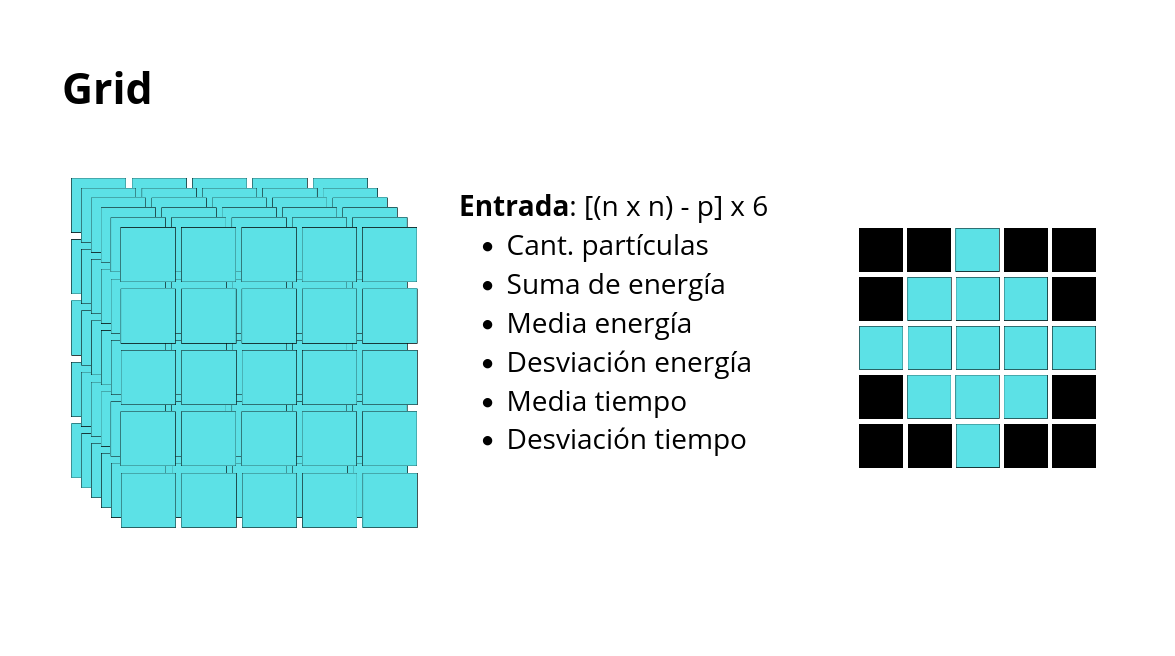

In [3]:
import torch

def grid_generator(df_particles, df_shower, n=8, device="cpu"):

    # convertir a torch 
    x = torch.tensor(df_particles["x"].values, dtype=torch.float32, device=device)
    y = torch.tensor(df_particles["y"].values, dtype=torch.float32, device=device)
    e = torch.tensor(np.log1p(df_particles["energy"]).values, dtype=torch.float32, device=device)
    t = torch.tensor(df_particles["t"].values, dtype=torch.float32, device=device)
    shower_id = torch.tensor(df_particles["shower"].values, dtype=torch.long, device=device)

    # mapear showers a índices 
    showers = df_particles.shower.unique()
    unique_showers, shower_idx = torch.unique(shower_id, return_inverse=True)
    n_showers = unique_showers.shape[0]

    # bins 
    x_bins = torch.linspace(x.min(), x.max(), n+1, device=device)
    y_bins = torch.linspace(y.min(), y.max(), n+1, device=device)

    ix = torch.bucketize(x, x_bins) - 1
    iy = torch.bucketize(y, y_bins) - 1

    # máscara válida 
    valid = (ix >= 0) & (ix < n) & (iy >= 0) & (iy < n)

    ix = ix[valid]
    iy = iy[valid]
    e = e[valid]
    t = t[valid]
    shower_idx = shower_idx[valid]

    # índice global 
    flat_idx = shower_idx * (n*n) + ix * n + iy

    # acumulaciones 
    size = n_showers * n * n

    count = torch.zeros(size, device=device)
    e_sum = torch.zeros(size, device=device)
    e_sq_sum = torch.zeros(size, device=device)
    t_sum = torch.zeros(size, device=device)
    t_sq_sum = torch.zeros(size, device=device)

    ones = torch.ones_like(e)

    count.scatter_add_(0, flat_idx, ones)
    e_sum.scatter_add_(0, flat_idx, e)
    e_sq_sum.scatter_add_(0, flat_idx, e**2)
    t_sum.scatter_add_(0, flat_idx, t)
    t_sq_sum.scatter_add_(0, flat_idx, t**2)

    # reshape
    count = count.view(n_showers, n, n)
    e_sum = e_sum.view(n_showers, n, n)

    # medias
    eps = 1e-8
    mask = count > 0

    e_mean = torch.zeros_like(e_sum)
    t_mean = torch.zeros_like(t_sum.view(n_showers, n, n))

    e_mean[mask] = e_sum[mask] / count[mask]
    t_mean[mask] = t_sum.view(n_showers, n, n)[mask] / count[mask]

    # varianzas
    e_var = e_sq_sum.view(n_showers, n, n)/(count+eps) - e_mean**2
    t_var = t_sq_sum.view(n_showers, n, n)/(count+eps) - t_mean**2

    # std seguras
    e_std = torch.sqrt(torch.clamp(e_var, min=0.0))
    t_std = torch.sqrt(torch.clamp(t_var, min=0.0))

    # stack final
    X = torch.stack([count, e_sum, e_mean, e_std, t_mean, t_std], dim=-1)

    # flatten 
    #X = X.view(n_showers, -1)

    # target
    mapping = {val.item(): i for i, val in enumerate(unique_showers)}
    df_shower["idx"] = df_shower["event_no"].map(mapping)
    df_shower = df_shower.dropna().sort_values("idx")

    y = torch.tensor(df_shower["total_energy"].values, dtype=torch.float32, device=device)

    y = torch.log1p(y)

    return X, y

X,y = grid_generator(particles, shower, n=10, device="cpu")
print(X.shape, y.shape)
print((torch.isnan(y)).any())

torch.Size([4977, 10, 10, 6]) torch.Size([4977])
tensor(False)


In [4]:
particles.shower.value_counts()

shower
3939    51301
3920    50028
1212    15400
2027    15333
2882    13077
        ...  
4710        1
4721        1
4878        1
4934        1
4983        1
Name: count, Length: 4977, dtype: int64

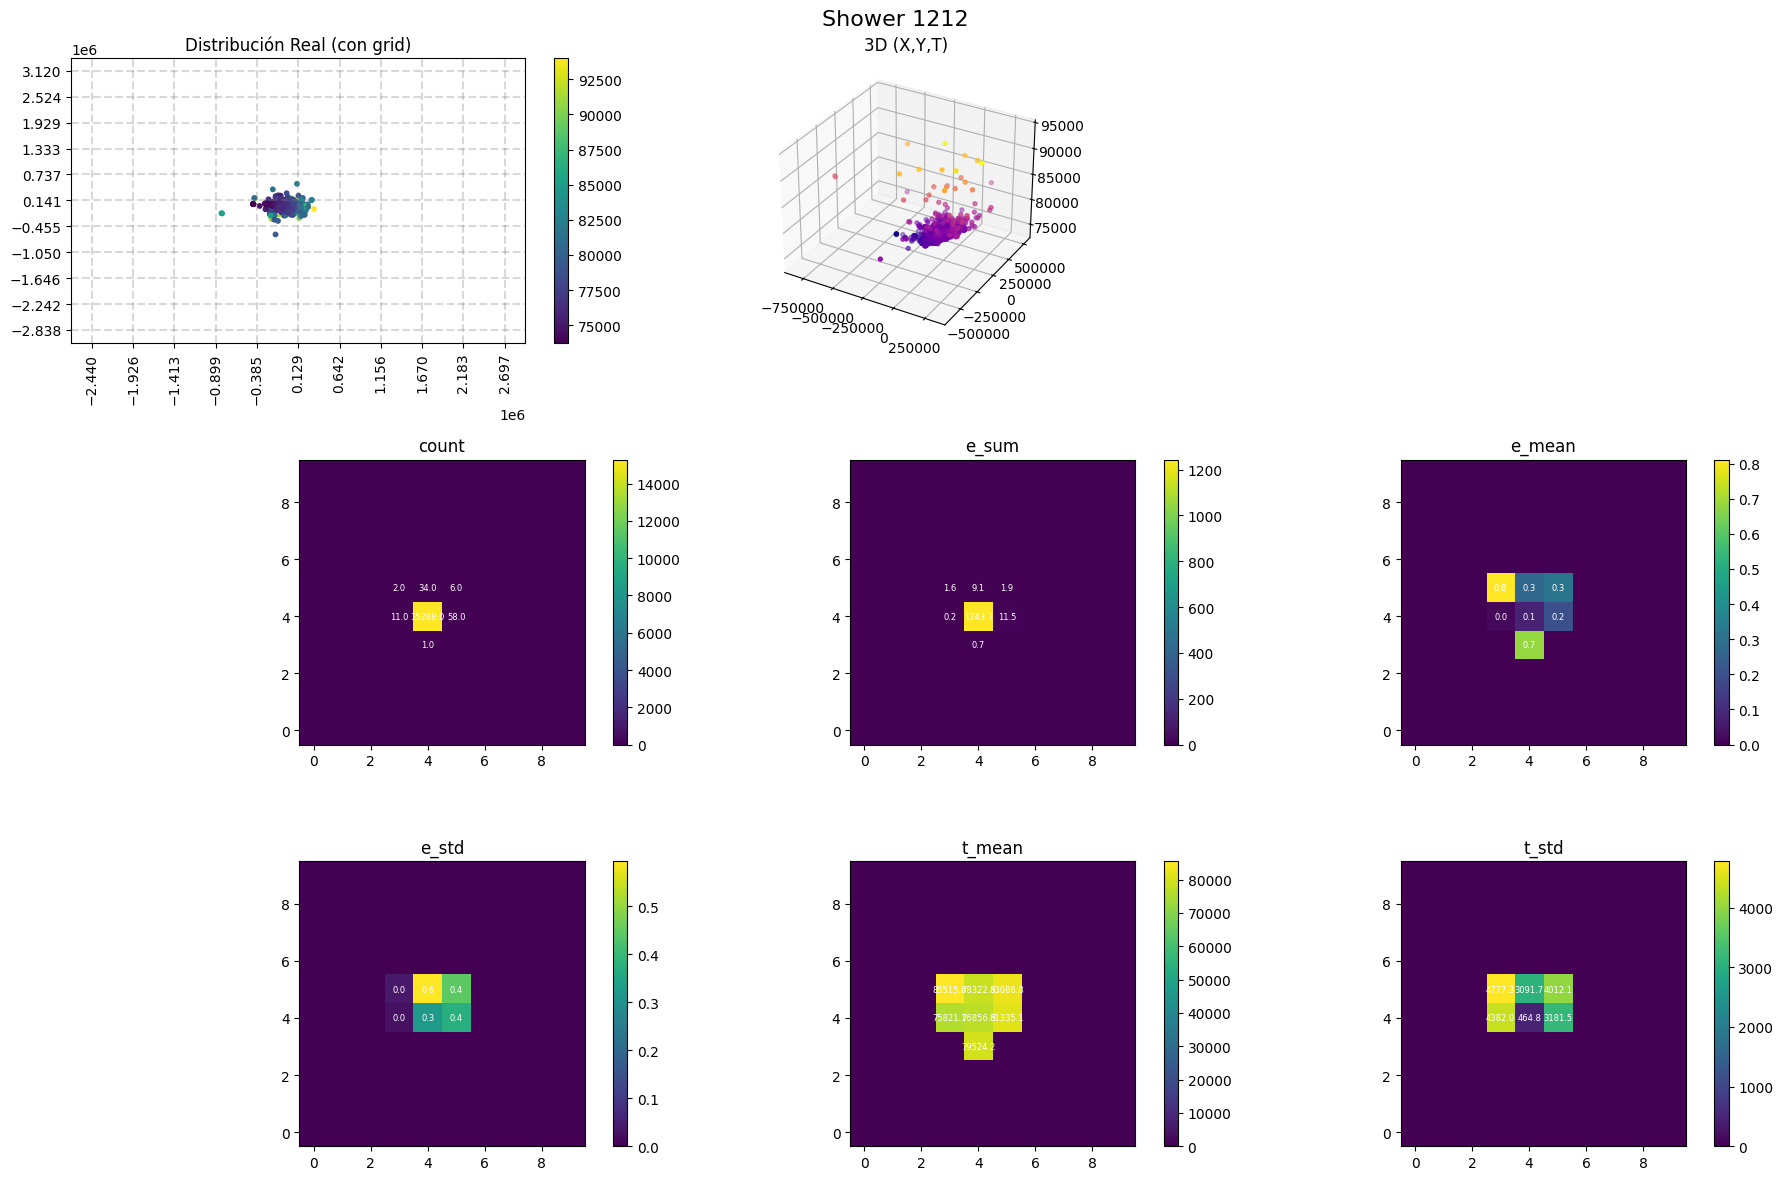

Max count: 15288.0
Total partículas: 15400


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_full_shower(grid_data, df_particles, event_id, n=8):

    # -------- seleccionar shower --------
    shower_data = df_particles[df_particles["shower"] == event_id]

    # -------- índice consistente --------
    unique_showers = np.sort(df_particles["shower"].unique())
    idx = np.where(unique_showers == event_id)[0][0]

    grid = grid_data[idx].reshape(n, n, 6)

    # -------- BINS GLOBALES (🔥 clave) --------
    x_bins = np.linspace(df_particles["x"].min(), df_particles["x"].max(), n+1)
    y_bins = np.linspace(df_particles["y"].min(), df_particles["y"].max(), n+1)

    # -------- nombres --------
    channel_names = [
        "count",
        "e_sum",
        "e_mean",
        "e_std",
        "t_mean",
        "t_std"
    ]

    # -------- FIGURA --------
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3)

    # =========================
    # 1. SCATTER REAL (con grid REAL)
    # =========================
    ax1 = fig.add_subplot(gs[0, 0])

    sc = ax1.scatter(
        shower_data["x"],
        shower_data["y"],
        c=shower_data["t"],
        cmap="viridis",
        s=10
    )

    # grid EXACTO
    for xb in x_bins:
        ax1.axvline(x=xb, color='gray', linestyle='--', alpha=0.3)
    for yb in y_bins:
        ax1.axhline(y=yb, color='gray', linestyle='--', alpha=0.3)

    ax1.set_title("Distribución Real (con grid)")
    plt.colorbar(sc, ax=ax1)

    # ticks alineados con bins
    ax1.set_xticks(x_bins)
    ax1.set_yticks(y_bins)

    # 🔥 rotar etiquetas X
    ax1.tick_params(axis='x', rotation=90)

    # =========================
    # 2. 3D
    # =========================
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')

    ax2.scatter(
        shower_data["x"],
        shower_data["y"],
        shower_data["t"],
        c=shower_data["t"],
        cmap="plasma",
        s=8
    )

    ax2.set_title("3D (X,Y,T)")

    # =========================
    # 3. GRID CHANNELS (3 + 3)
    # =========================
    for i in range(6):

        row = 1 + i // 3
        col = i % 3

        ax = fig.add_subplot(gs[row, col])

        layer = grid[:, :, i].T

        im = ax.imshow(layer, origin="lower", cmap="viridis")

        ax.set_title(channel_names[i])

        # números
        for xi in range(n):
            for yi in range(n):
                val = layer[xi, yi]
                if val != 0:
                    ax.text(
                        yi, xi,
                        f"{val:.1f}",
                        ha='center',
                        va='center',
                        color='white',
                        fontsize=6
                    )

        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(f"Shower {event_id}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # debug
    print("Max count:", grid[:,:,0].max())
    print("Total partículas:", len(shower_data))

plot_full_shower(X.numpy(), particles, event_id=1212, n=10)

---

## **Círculos**


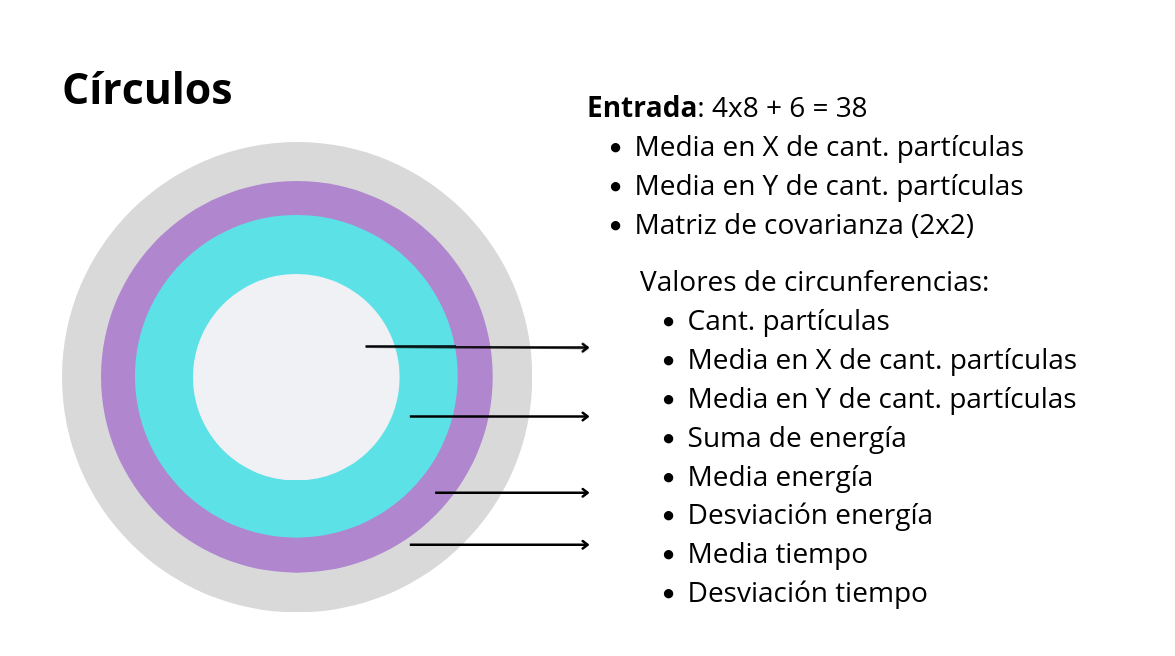

In [10]:
import torch
import numpy as np

def circle_generator(df_particles, df_shower, device="cpu"):

    # -------- tensors --------
    x = torch.tensor(df_particles["x"].values, dtype=torch.float32, device=device)
    y = torch.tensor(df_particles["y"].values, dtype=torch.float32, device=device)
    e = torch.tensor(np.log1p(df_particles["energy"].values), dtype=torch.float32, device=device)
    t = torch.tensor(df_particles["t"].values, dtype=torch.float32, device=device)
    shower_id = torch.tensor(df_particles["shower"].values, dtype=torch.long, device=device)

    # -------- mapping --------
    unique_showers, shower_idx = torch.unique(shower_id, return_inverse=True)
    n_showers = unique_showers.shape[0]

    # -------- medias por shower --------
    count = torch.zeros(n_showers, device=device)
    x_sum = torch.zeros(n_showers, device=device)
    y_sum = torch.zeros(n_showers, device=device)

    ones = torch.ones_like(x)

    count.scatter_add_(0, shower_idx, ones)
    x_sum.scatter_add_(0, shower_idx, x)
    y_sum.scatter_add_(0, shower_idx, y)

    x_mean = x_sum / (count + 1e-8)
    y_mean = y_sum / (count + 1e-8)

    # -------- centrar --------
    x_c = x - x_mean[shower_idx]
    y_c = y - y_mean[shower_idx]

    r = torch.sqrt(x_c**2 + y_c**2)

    # -------- sigma radial --------
    r_sum = torch.zeros(n_showers, device=device)
    r_sq_sum = torch.zeros(n_showers, device=device)

    r_sum.scatter_add_(0, shower_idx, r)
    r_sq_sum.scatter_add_(0, shower_idx, r**2)

    r_mean = r_sum / (count + 1e-8)
    r_var = r_sq_sum/(count+1e-8) - r_mean**2
    sigma = torch.sqrt(torch.clamp(r_var, min=0.0))

    # -------- bins --------
    r_bins = torch.stack([sigma * i for i in range(1,5)], dim=1)  # (n_showers, 4)

    # -------- asignar anillos --------
    # expandir para comparar
    r_exp = r.unsqueeze(1)  # (N_particles, 1)
    bins = r_bins[shower_idx]  # (N_particles, 4)

    ring_idx = torch.zeros_like(r, dtype=torch.long)

    ring_idx += (r > bins[:,0])
    ring_idx += (r > bins[:,1])
    ring_idx += (r > bins[:,2])
    ring_idx += (r > bins[:,3])

    ring_idx = torch.clamp(ring_idx, max=3)

    # -------- índice combinado (shower + ring) --------
    flat_idx = shower_idx * 4 + ring_idx
    size = n_showers * 4

    # -------- acumulaciones --------
    count_r = torch.zeros(size, device=device)
    e_sum = torch.zeros(size, device=device)
    e_sq_sum = torch.zeros(size, device=device)
    t_sum = torch.zeros(size, device=device)
    t_sq_sum = torch.zeros(size, device=device)

    count_r.scatter_add_(0, flat_idx, ones)
    e_sum.scatter_add_(0, flat_idx, e)
    e_sq_sum.scatter_add_(0, flat_idx, e**2)
    t_sum.scatter_add_(0, flat_idx, t)
    t_sq_sum.scatter_add_(0, flat_idx, t**2)

    # -------- reshape --------
    count_r = count_r.view(n_showers, 4)
    e_sum = e_sum.view(n_showers, 4)
    t_sum = t_sum.view(n_showers, 4)

    # -------- medias --------
    mask = count_r > 0

    e_mean = torch.zeros_like(e_sum)
    t_mean = torch.zeros_like(t_sum)

    e_mean[mask] = e_sum[mask] / count_r[mask]
    t_mean[mask] = t_sum[mask] / count_r[mask]

    # -------- std --------
    e_var = e_sq_sum.view(n_showers,4)/(count_r+1e-8) - e_mean**2
    t_var = t_sq_sum.view(n_showers,4)/(count_r+1e-8) - t_mean**2

    e_std = torch.sqrt(torch.clamp(e_var, min=0.0))
    t_std = torch.sqrt(torch.clamp(t_var, min=0.0))

    # -------- features --------
    features = torch.stack([
        count_r,
        e_sum,
        e_mean,
        e_std,
        t_mean,
        t_std
    ], dim=2)  # (n_showers, 4, 6)

    features = features.view(n_showers, -1)  # (n_showers, 24)

    # -------- covarianza --------
    xx = torch.zeros(n_showers, device=device)
    yy = torch.zeros(n_showers, device=device)
    xy = torch.zeros(n_showers, device=device)

    xx.scatter_add_(0, shower_idx, x_c**2)
    yy.scatter_add_(0, shower_idx, y_c**2)
    xy.scatter_add_(0, shower_idx, x_c*y_c)

    cov_xx = xx / (count + 1e-8)
    cov_yy = yy / (count + 1e-8)
    cov_xy = xy / (count + 1e-8)

    cov = torch.stack([cov_xx, cov_xy, cov_xy, cov_yy], dim=1)

    # -------- final --------
    X = torch.cat([
        x_mean.unsqueeze(1),
        y_mean.unsqueeze(1),
        cov,
        features
    ], dim=1)

    # -------- target --------
    mapping = {val.item(): i for i, val in enumerate(unique_showers)}
    df_shower["idx"] = df_shower["event_no"].map(mapping)
    df_shower = df_shower.dropna().sort_values("idx")

    y = torch.tensor(df_shower["total_energy"].values, dtype=torch.float32, device=device)
    y = torch.log1p(y)

    return X, y

X,y = circle_generator(particles, shower, device="cpu")
print(X.shape, y.shape)
print((torch.isnan(y)).any())


torch.Size([4977, 30]) torch.Size([4977])
tensor(False)


---

## **Estadístico**
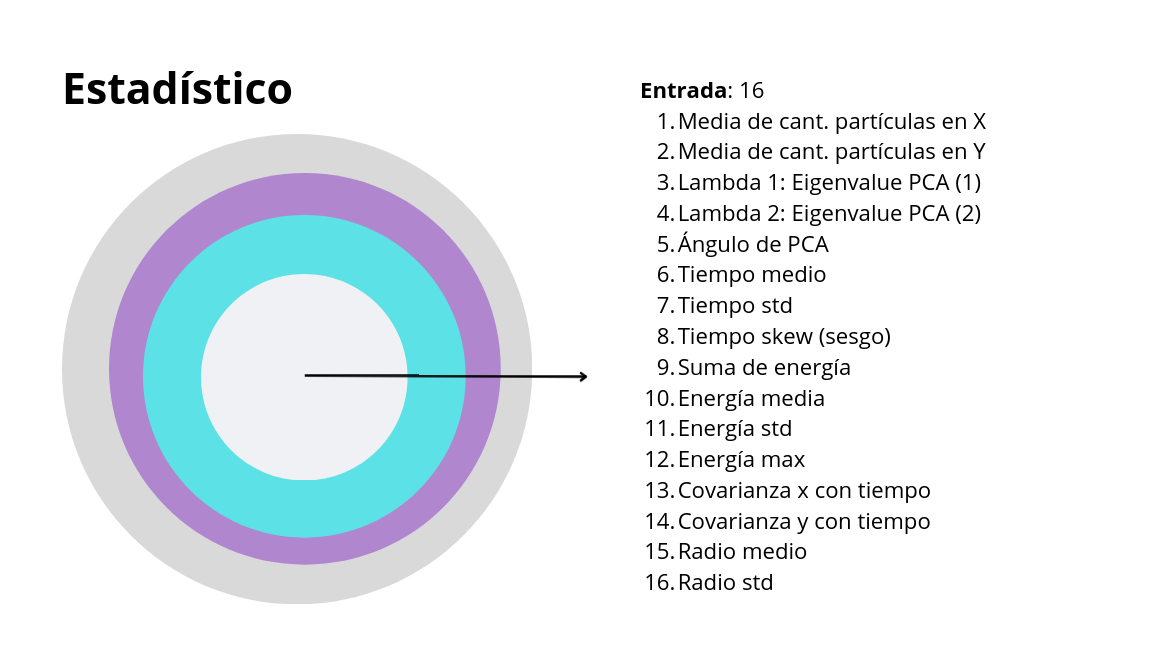

In [8]:
import torch
import numpy as np

def stats_generator_torch(df_particles, df_shower, device="cpu"):

    # -------- tensors --------
    x = torch.tensor(df_particles["x"].values, dtype=torch.float32, device=device)
    y = torch.tensor(df_particles["y"].values, dtype=torch.float32, device=device)
    t = torch.tensor(df_particles["t"].values, dtype=torch.float32, device=device)
    e = torch.tensor(np.log1p(df_particles["energy"].values), dtype=torch.float32, device=device)
    shower_id = torch.tensor(df_particles["shower"].values, dtype=torch.long, device=device)

    # -------- mapping --------
    unique_showers, shower_idx = torch.unique(shower_id, return_inverse=True)
    n_showers = unique_showers.shape[0]

    ones = torch.ones_like(x)

    # -------- conteo --------
    count = torch.zeros(n_showers, device=device)
    count.scatter_add_(0, shower_idx, ones)

    # -------- medias --------
    x_sum = torch.zeros(n_showers, device=device)
    y_sum = torch.zeros(n_showers, device=device)
    t_sum = torch.zeros(n_showers, device=device)
    e_sum = torch.zeros(n_showers, device=device)

    x_sum.scatter_add_(0, shower_idx, x)
    y_sum.scatter_add_(0, shower_idx, y)
    t_sum.scatter_add_(0, shower_idx, t)
    e_sum.scatter_add_(0, shower_idx, e)

    x_mean = x_sum / (count + 1e-8)
    y_mean = y_sum / (count + 1e-8)
    t_mean = t_sum / (count + 1e-8)
    e_mean = e_sum / (count + 1e-8)

    # -------- varianzas --------
    x_c = x - x_mean[shower_idx]
    y_c = y - y_mean[shower_idx]
    t_c = t - t_mean[shower_idx]
    e_c = e - e_mean[shower_idx]

    x_var = torch.zeros(n_showers, device=device)
    y_var = torch.zeros(n_showers, device=device)
    t_var = torch.zeros(n_showers, device=device)
    e_var = torch.zeros(n_showers, device=device)

    x_var.scatter_add_(0, shower_idx, x_c**2)
    y_var.scatter_add_(0, shower_idx, y_c**2)
    t_var.scatter_add_(0, shower_idx, t_c**2)
    e_var.scatter_add_(0, shower_idx, e_c**2)

    x_var /= (count + 1e-8)
    y_var /= (count + 1e-8)
    t_var /= (count + 1e-8)
    e_var /= (count + 1e-8)

    t_std = torch.sqrt(torch.clamp(t_var, min=0.0))

    # -------- skew (aproximado) --------
    t_skew = torch.zeros(n_showers, device=device)
    t_skew.scatter_add_(0, shower_idx, t_c**3)
    t_skew = t_skew / (count + 1e-8)
    t_skew = t_skew / (t_std**3 + 1e-8)

    # -------- energía --------
    e_max = torch.zeros(n_showers, device=device)
    e_max.scatter_reduce_(0, shower_idx, e, reduce="amax", include_self=False)

    # -------- covarianzas --------
    cov_xt = torch.zeros(n_showers, device=device)
    cov_yt = torch.zeros(n_showers, device=device)

    cov_xt.scatter_add_(0, shower_idx, x_c * t_c)
    cov_yt.scatter_add_(0, shower_idx, y_c * t_c)

    cov_xt /= (count + 1e-8)
    cov_yt /= (count + 1e-8)

    # -------- radio --------
    r = torch.sqrt(x_c**2 + y_c**2)

    r_sum = torch.zeros(n_showers, device=device)
    r_sq_sum = torch.zeros(n_showers, device=device)

    r_sum.scatter_add_(0, shower_idx, r)
    r_sq_sum.scatter_add_(0, shower_idx, r**2)

    r_mean = r_sum / (count + 1e-8)
    r_var = r_sq_sum/(count+1e-8) - r_mean**2

    # -------- PCA (aproximación torch) --------
    cov_xx = x_var
    cov_yy = y_var

    cov_xy = torch.zeros(n_showers, device=device)
    cov_xy.scatter_add_(0, shower_idx, x_c * y_c)
    cov_xy /= (count + 1e-8)

    # eigenvalues analíticos 2x2
    trace = cov_xx + cov_yy
    det = cov_xx * cov_yy - cov_xy**2

    temp = torch.sqrt(torch.clamp(trace**2 - 4*det, min=0.0))

    lambda1 = (trace + temp) / 2
    lambda2 = (trace - temp) / 2

    # ángulo
    angle = 0.5 * torch.atan2(2*cov_xy, cov_xx - cov_yy)

    # -------- final --------
    X = torch.stack([
        x_mean,
        y_mean,
        lambda1,
        lambda2,
        angle,
        t_mean,
        t_std,
        t_skew,
        e_sum,
        e_mean,
        e_var,
        e_max,
        cov_xt,
        cov_yt,
        r_mean,
        r_var
    ], dim=1)

    # -------- target alineado --------
    mapping = {val.item(): i for i, val in enumerate(unique_showers)}
    df_shower["idx"] = df_shower["event_no"].map(mapping)
    df_shower = df_shower.dropna().sort_values("idx")

    y = torch.tensor(df_shower["total_energy"].values, dtype=torch.float32, device=device)
    y = torch.log1p(y)

    return X, y

X,y = stats_generator_torch(particles, shower, device="cpu")
print(X.shape, y.shape)
print((torch.isnan(y)).any())

torch.Size([4977, 16]) torch.Size([4977])
tensor(False)


---

## **Split**

In [9]:
from torch.utils.data import TensorDataset, DataLoader

def split_data(X, y, train=0.7, val=0.15):

    n = X.shape[0]
    idx = torch.randperm(n)

    n_train = int(train * n)
    n_val   = int(val * n)

    train_idx = idx[:n_train]
    val_idx   = idx[n_train:n_train+n_val]
    test_idx  = idx[n_train+n_val:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val     = X[val_idx], y[val_idx]
    X_test, y_test   = X[test_idx], y[test_idx]

    # -------- normalización correcta --------
    X_mean = X_train.mean(dim=0)
    X_std  = X_train.std(dim=0) + 1e-8

    X_train = (X_train - X_mean) / X_std
    X_val   = (X_val   - X_mean) / X_std
    X_test  = (X_test  - X_mean) / X_std

    # -------- clipping extra (anti-explosión) --------
    X_train = torch.clamp(X_train, -5, 5)
    X_val   = torch.clamp(X_val, -5, 5)
    X_test  = torch.clamp(X_test, -5, 5)

    train_ds = TensorDataset(X_train, y_train.view(-1,1))
    val_ds   = TensorDataset(X_val,   y_val.view(-1,1))
    test_ds  = TensorDataset(X_test,  y_test.view(-1,1))

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_data(X, y)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)